In [1]:
import pandas as pd
import numpy as np
import torch
import optuna
import scipy as sp
from functools import partial
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score

# ---------------------------------------------------------
# 1. CARGA Y PREPROCESAMIENTO 
# ---------------------------------------------------------

# Cargar datos
df = pd.read_csv(r"C:\Users\jmolina\Grupo Sancor Seguros\CURSO\Maestría\Labo_2\Archivo\train.csv")
df_breeds = pd.read_csv(r"C:\Users\jmolina\Grupo Sancor Seguros\CURSO\Maestría\Labo_2\Archivo\breed_labels.csv")

In [2]:
# 1. Cargar el dataset original

def categorizar_tamano(row):
    breed = str(row['BreedName']).lower()
    pet_type = row['Type']
    
    # Gatos (Type = 2): Los clasificamos como 'Pequeño' por defecto en comparación a un perro
    if pet_type == 2:
        return 'Pequeño'
        
    # Perros (Type = 1)
    if 'mixed breed' in breed:
        return 'Mediano' # Promedio estadístico seguro para perros mestizos
        
    # A. Excepciones específicas (se evalúan antes que las reglas generales)
    excepciones_grandes = ['black russian terrier', 'airedale terrier', 'afghan hound', 'bloodhound', 'greyhound', 'irish wolfhound']
    excepciones_medianos = ['american staffordshire terrier', 'pit bull terrier', 'bull terrier', 'beagle', 'basset hound', 'whippet', 'standard schnauzer', 'cocker spaniel']
    excepciones_pequenos = ['dachshund', 'miniature schnauzer', 'toy', 'miniature']
    
    if any(exc in breed for exc in excepciones_grandes):
        return 'Grande'
    if any(exc in breed for exc in excepciones_medianos):
        return 'Mediano'
    if any(exc in breed for exc in excepciones_pequenos):
        return 'Pequeño'
        
    # B. Reglas generales por familias funcionales / palabras clave
    # La mayoría de los terriers y perros de compañía son pequeños
    keywords_pequenos = ['terrier', 'chihuahua', 'pomeranian', 'pug', 'shih tzu', 'maltese', 'pekingese', 'corgi', 'bichon', 'french bulldog', 'papillon', 'havanese', 'pinscher']
    
    # La mayoría de los pastores, cobradores, mastines y sabuesos son grandes
    keywords_grandes = ['retriever', 'shepherd', 'mastiff', 'great', 'husky', 'malamute', 'akita', 'hound', 'pointer', 'setter', 'collie', 'rottweiler', 'doberman', 'boxer', 'american bulldog', 'sheepdog', 'dane', 'bernard', 'pyrenees', 'newfoundland', 'weimaraner', 'ridgeback', 'corso', 'komondor', 'kuvasz', 'borzoi', 'dalmatian']
    
    if any(kw in breed for kw in keywords_pequenos):
        return 'Pequeño'
    if any(kw in breed for kw in keywords_grandes):
        return 'Grande'
        
    # C. Todo lo que no caiga en las reglas anteriores se asume Mediano (ej. Spaniels, Bulldogs ingleses, Spitz)
    return 'Mediano'

# 2. Aplicar la función para crear la nueva columna
df_breeds['SizeCategory'] = df_breeds.apply(categorizar_tamano, axis=1)

In [3]:
# A. Cruzar con Tamaño de Raza
df = df.merge(df_breeds[['BreedID', 'SizeCategory']], left_on='Breed1', right_on='BreedID', how='left')
df['SizeCategory'] = df['SizeCategory'].fillna('Mediano')

# B. Crear Is_Purebred (Raza Pura)
df['Is_Purebred'] = np.where((df['Breed2'] == 0) | (df['Breed1'] == df['Breed2']), 1, 0)

# C. Solución a Alta Cardinalidad: Frequency Encoding para RescuerID
rescuer_counts = df['RescuerID'].value_counts().to_dict()
df['Rescuer_Count'] = df['RescuerID'].map(rescuer_counts)

In [4]:
#1. Definimos qué columnas NO queremos que el modelo vea (IDs y texto libre)
drop_cols = ['AdoptionSpeed', 'PetID', 'Name', 'RescuerID', 'Description', 'BreedID']
features = [c for c in df.columns if c not in drop_cols]

# 2. Identificamos automáticamente TODAS las columnas que son texto (object)
# Esto incluye 'SizeCategory' y cualquier otra que se haya colado
categorical_cols = df[features].select_dtypes(include=['object', 'category']).columns.tolist()

cat_idxs = []
cat_dims = []

for idx, col in enumerate(features):
    if col in categorical_cols:
        # Aseguramos que no haya nulos y convertimos a string antes de codificar
        df[col] = df[col].fillna("None").astype(str)
        
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        
        cat_idxs.append(idx)
        cat_dims.append(len(le.classes_))
    else:
        # Para las columnas numéricas, nos aseguramos de que no tengan NaNs
        # porque las redes neuronales no aceptan NaNs (Infinity)
        df[col] = df[col].fillna(0)

# Verificación final: Si esto imprime algo, aún hay problemas
print("Columnas que NO son números:", df[features].select_dtypes(exclude=[np.number]).columns.tolist())

Columnas que NO son números: []


In [5]:
# ---------------------------------------------------------
# 2. OPTIMIZADOR DE UMBRALES (OPTIMIZED ROUNDER)
# ---------------------------------------------------------

class OptimizedRounder:
    def __init__(self):
        # Iniciamos con umbrales lógicos para las 5 clases (0 a 4)
        self.coef_ = [1.0, 2.0, 2.5, 3.0]

    def _kappa_loss(self, coef, X, y):
        X_p = np.digitize(X, np.sort(coef))
        return -cohen_kappa_score(y, X_p, weights='quadratic')

    def fit(self, X, y):
        loss_partial = partial(self._kappa_loss, X=X, y=y)
        res = sp.optimize.minimize(loss_partial, self.coef_, method='nelder-mead')
        self.coef_ = np.sort(res['x'])

    def predict(self, X):
        return np.digitize(X, self.coef_)

# ---------------------------------------------------------
# 3. CONFIGURACIÓN DE OPTUNA PARA TABNET
# ---------------------------------------------------------

def objective(trial):
    params = {
        'n_d': trial.suggest_int('n_d', 8, 64),
        'n_a': trial.suggest_int('n_a', 8, 64),
        'n_steps': trial.suggest_int('n_steps', 3, 10),
        'gamma': trial.suggest_float('gamma', 1.0, 2.0),
        'lambda_sparse': trial.suggest_float('lambda_sparse', 1e-6, 1e-3, log=True),
        'optimizer_params': dict(lr=2e-2),
        'mask_type': 'entmax',
        'seed': 42,
        'verbose': 0
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    val_kappas = []
    
    # Aseguramos que usamos los datos procesados del CSV
    X = df[features].values
    y = df['AdoptionSpeed'].values

    for trn_idx, val_idx in skf.split(X, y):
        # CORRECCIÓN DE INDEXACIÓN: y_tr debe usar trn_idx, no val_idx
        X_tr, y_tr = X[trn_idx], y[trn_idx] 
        X_val, y_val = X[val_idx], y[val_idx]
        
        regressor = TabNetRegressor(cat_idxs=cat_idxs, cat_dims=cat_dims, **params)
        
        regressor.fit(
            X_train=X_tr, y_train=y_tr.reshape(-1, 1),
            eval_set=[(X_val, y_val.reshape(-1, 1))],
            eval_metric=['rmse'],
            max_epochs=100, 
            patience=15, 
            batch_size=1024, 
            virtual_batch_size=128
        )
        
        # Predicciones crudas (decimales)
        preds_raw = regressor.predict(X_val).flatten()
        
        # Ajuste de umbrales para maximizar Kappa
        optR = OptimizedRounder()
        optR.fit(preds_raw, y_val)
        
        # Cálculo de la métrica objetivo del laboratorio
        kappa = cohen_kappa_score(y_val, optR.predict(preds_raw), weights='quadratic')
        val_kappas.append(kappa)

    return np.mean(val_kappas)

#  Crear y ejecutar el estudio
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print(f"Mejor Kappa: {study.best_value}")
print(f"Mejores parámetros: {study.best_params}")

[I 2026-04-28 13:56:13,598] A new study created in memory with name: no-name-54202cdd-355a-46ba-a68b-05d94ffcedd7



Early stopping occurred at epoch 74 with best_epoch = 59 and best_val_0_rmse = 1.11877


c:\Users\jmolina\AppData\Local\Programs\Python\Python312\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 70 with best_epoch = 55 and best_val_0_rmse = 1.10469


c:\Users\jmolina\AppData\Local\Programs\Python\Python312\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


...


Early stopping occurred at epoch 27 with best_epoch = 12 and best_val_0_rmse = 1.43738


c:\Users\jmolina\AppData\Local\Programs\Python\Python312\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 64 with best_epoch = 49 and best_val_0_rmse = 1.0781


c:\Users\jmolina\AppData\Local\Programs\Python\Python312\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-04-28 19:01:15,903] Trial 19 finished with value: 0.2996344482419281 and parameters: {'n_d': 15, 'n_a': 49, 'n_steps': 8, 'gamma': 1.0018222096169422, 'lambda_sparse': 0.00025614352505849307}. Best is trial 18 with value: 0.38303431707296526.


Mejor Kappa: 0.38303431707296526
Mejores parámetros: {'n_d': 16, 'n_a': 48, 'n_steps': 8, 'gamma': 1.0168168076162083, 'lambda_sparse': 3.475715163340009e-05}


Entrenando el modelo final con Sample Weights...

Early stopping occurred at epoch 98 with best_epoch = 78 and best_val_0_rmse = 1.19997


c:\Users\jmolina\AppData\Local\Programs\Python\Python312\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



--- ANÁLISIS DE CORTES MATEMÁTICOS ---
Corte 0 a 1: 1.0050
Corte 1 a 2: 2.0196
Corte 2 a 3: 2.5178
Corte 3 a 4: 3.0226


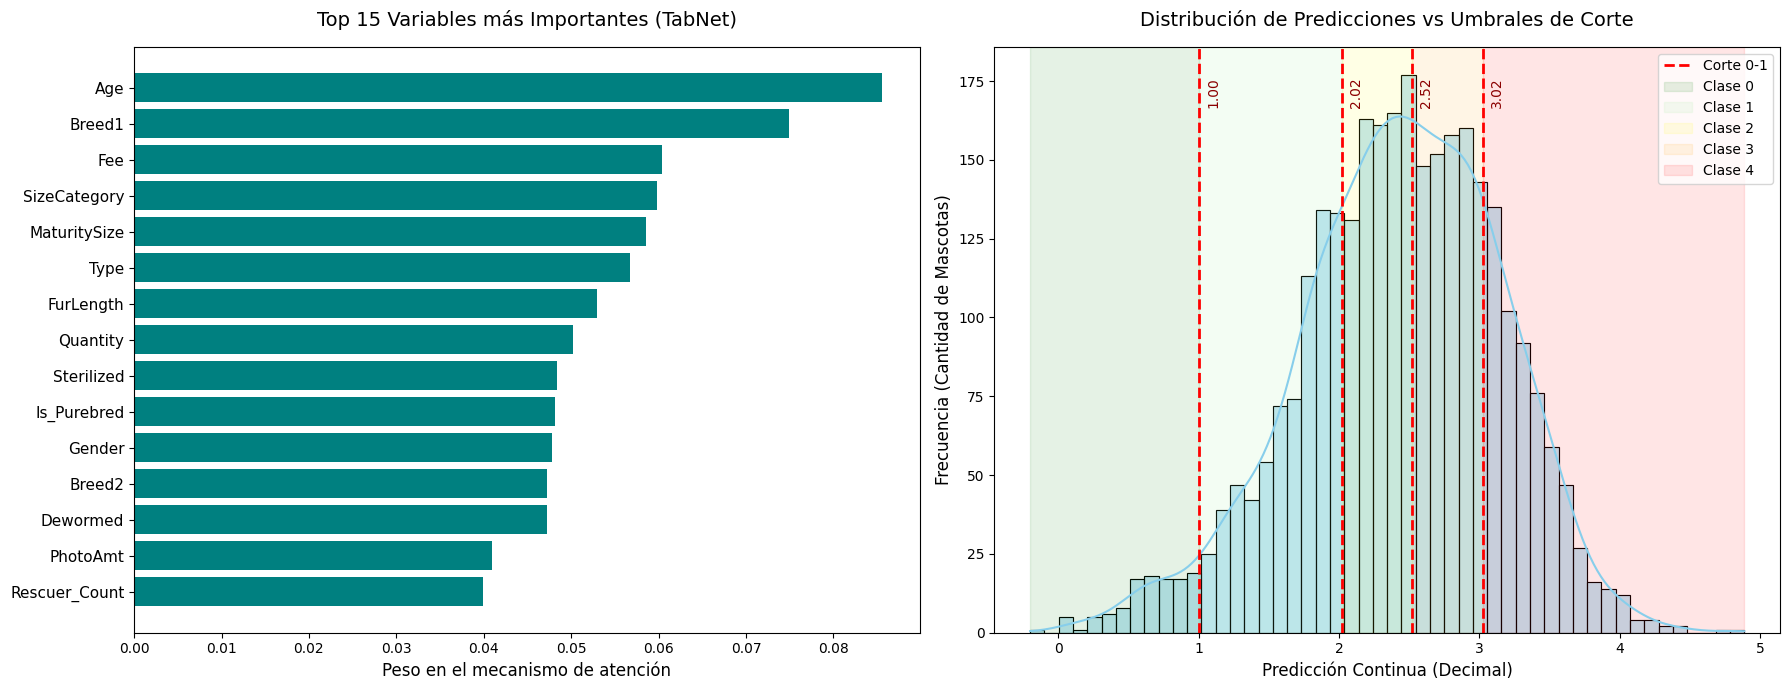

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

# 1. Separar un set de validación final honesto para medir los cortes reales
X_all = df[features].values
y_all = df['AdoptionSpeed'].values

X_train_fin, X_val_fin, y_train_fin, y_val_fin = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# 2. Configurar y entrenar el modelo FINAL con los parámetros de Optuna
final_params = study.best_params
final_params.update({
    'cat_idxs': cat_idxs,
    'cat_dims': cat_dims,
    'cat_emb_dim': 2,
    'optimizer_fn': torch.optim.Adam,
    'optimizer_params': dict(lr=2e-2),
    'mask_type': 'entmax',
    'seed': 42,
    'verbose': 0
})

# A. Calcular los pesos balanceados
# Esto le asignará un peso muy alto a las mascotas de Clase 0 (minoritarias) 
# y un peso normal/bajo a las de Clase 2 o 3 (mayoritarias).
pesos_entrenamiento = compute_sample_weight('balanced', y_train_fin)

print("Entrenando el modelo final con Sample Weights...")
final_model = TabNetRegressor(**final_params)

# B. Inyectar los pesos en la función fit
final_model.fit(
    X_train=X_train_fin, 
    y_train=y_train_fin.reshape(-1, 1),
    eval_set=[(X_val_fin, y_val_fin.reshape(-1, 1))],
    eval_metric=['rmse'],
    max_epochs=150, 
    patience=20, 
    batch_size=1024, 
    virtual_batch_size=128,
    weights=pesos_entrenamiento # <--- ESTA ES LA CLAVE MÁGICA
)

# 3. Calcular los Coeficientes Óptimos en el set de validación
preds_val = final_model.predict(X_val_fin).flatten()
optR = OptimizedRounder()
optR.fit(preds_val, y_val_fin)
cortes_optimos = optR.coef_

print(f"\n--- ANÁLISIS DE CORTES MATEMÁTICOS ---")
print(f"Corte 0 a 1: {cortes_optimos[0]:.4f}")
print(f"Corte 1 a 2: {cortes_optimos[1]:.4f}")
print(f"Corte 2 a 3: {cortes_optimos[2]:.4f}")
print(f"Corte 3 a 4: {cortes_optimos[3]:.4f}")

# ==========================================
# 4. ZONA DE GRAFICACIÓN (PLOTS)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# GRÁFICO 1: Importancia de Variables (Feature Importance)
importances = final_model.feature_importances_
# Filtrar para mostrar solo el Top 15 de variables más importantes
indices = np.argsort(importances)[-15:] 

ax1.set_title("Top 15 Variables más Importantes (TabNet)", fontsize=14, pad=15)
ax1.barh(range(len(indices)), importances[indices], color='teal', align='center')
ax1.set_yticks(range(len(indices)))
ax1.set_yticklabels([features[i] for i in indices], fontsize=11)
ax1.set_xlabel('Peso en el mecanismo de atención', fontsize=12)

# GRÁFICO 2: Distribución de Predicciones vs Cortes
ax2.set_title("Distribución de Predicciones vs Umbrales de Corte", fontsize=14, pad=15)
sns.histplot(preds_val, bins=50, kde=True, color='skyblue', ax=ax2)

# Dibujar los umbrales de corte como líneas verticales rojas
for idx, corte in enumerate(cortes_optimos):
    ax2.axvline(corte, color='red', linestyle='--', linewidth=2, 
                label=f'Corte {idx}-{idx+1}' if idx==0 else "")
    ax2.text(corte + 0.05, ax2.get_ylim()[1]*0.9, f"{corte:.2f}", color='darkred', rotation=90)

# Colorear sutilmente los "segmentos" de cada clase
ax2.axvspan(preds_val.min(), cortes_optimos[0], alpha=0.1, color='green', label='Clase 0')
ax2.axvspan(cortes_optimos[0], cortes_optimos[1], alpha=0.1, color='lightgreen', label='Clase 1')
ax2.axvspan(cortes_optimos[1], cortes_optimos[2], alpha=0.1, color='yellow', label='Clase 2')
ax2.axvspan(cortes_optimos[2], cortes_optimos[3], alpha=0.1, color='orange', label='Clase 3')
ax2.axvspan(cortes_optimos[3], preds_val.max(), alpha=0.1, color='red', label='Clase 4')

ax2.set_xlabel('Predicción Continua (Decimal)', fontsize=12)
ax2.set_ylabel('Frecuencia (Cantidad de Mascotas)', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()